# Using PAGA trajectory and CytoTRACE scores generated in 2026-04-12_AllDC_DC2_Cytotrace.jpynb to predict trajectory

In [1]:
#load packages I need
import os
import tools
import scanpy as sc
import pandas as pd
import dandelion as ddl
from tqdm import tqdm
import matplotlib.pyplot as plt
import scanpy.external as sce
from matplotlib.pyplot import rc_context
import seaborn as sns

/home/s4436039/miniforge3/envs/envpy26/lib/python3.10/site-packages/nxviz/__init__.py:33: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)



In [2]:
#set current directory 
os.chdir('/scratch/user/s4436039/scdata/Myeloid_Objects')
os.getcwd()

'/scratch/user/s4436039/scdata/Myeloid_Objects'

In [3]:
# read in data
data_DC = sc.read_h5ad('20260412_AllDC_Cytotrace.h5ad')
data_DC2 = sc.read_h5ad('20260412_DC2_Cytotrace.h5ad')

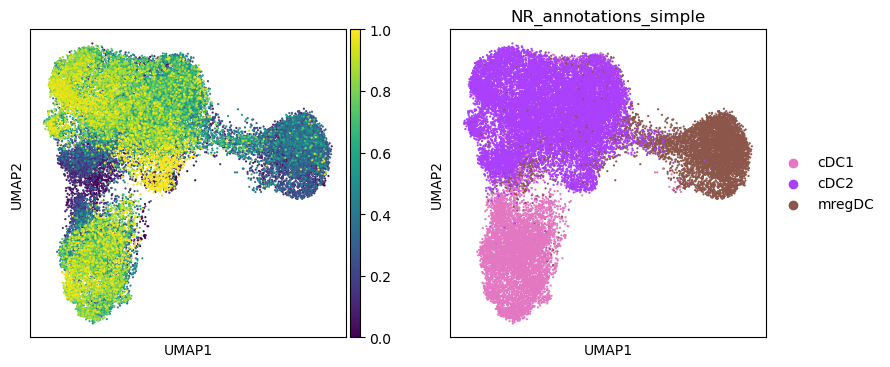

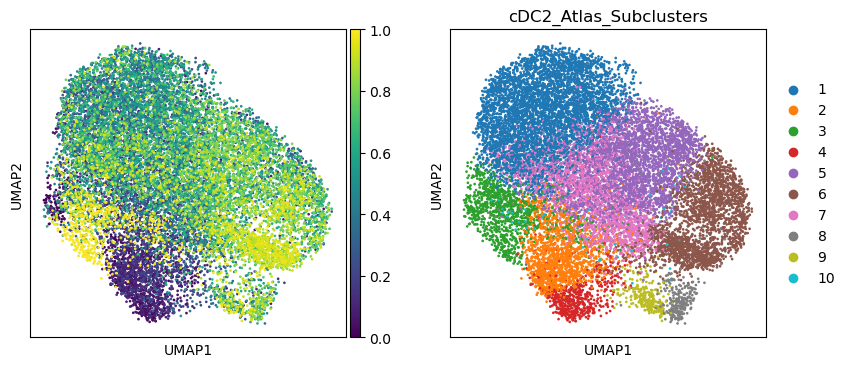

In [4]:
#plot cytotrace predictions. 1 --> less diff., 0 --> more diff.
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(data_DC, color=["CytoTRACE_DC_Predicted_order_2026","NR_annotations_simple"], size=10, title="")
    sc.pl.umap(data_DC2, color=["CytoTRACE_DC2_Predicted_order_2026","cDC2_Atlas_Subclusters"], size=15, title="")

# Running PAGA on DC2

In [5]:
sc.tl.paga(data_DC2, groups="cDC2_Atlas_Subclusters")

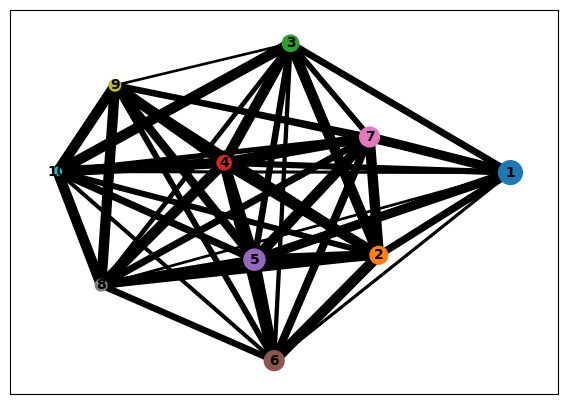

In [6]:
sc.pl.paga(data_DC2, color=["cDC2_Atlas_Subclusters"])

In [7]:
# annotate for paga
data_DC2.obs["paga_anno"] = data_DC2.obs["cDC2_Atlas_Subclusters"].cat.rename_categories(
    {
        "1": "1/DC3-like",
        "2": "2/undefined",
        "3": "3/IL-1B cDC2",
        "4": "4/CD207/LTB cDC2",
        "5": "5/cDC2",
        "6": "6/ascites cDC2",
        "7": "7/cDC2",
        "8": "8/CD207/LTB cDC2",
        "9": "9/CD207/LTB cDC2",
        "10": "10/CD207/LTB cDC2",
    }
)

In [8]:
sc.tl.paga(data_DC2, groups="paga_anno")

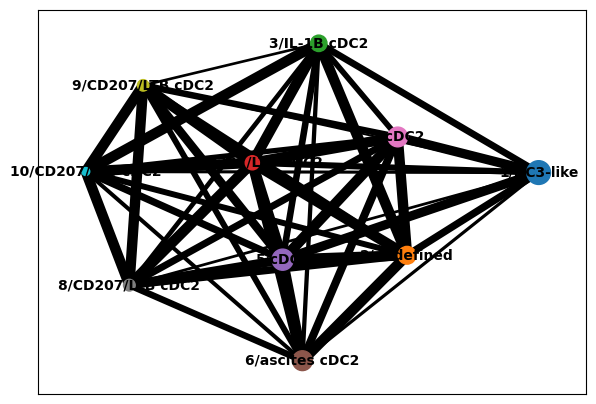

In [11]:
sc.pl.paga(data_DC2, threshold=0.03)

In [25]:
import matplotlib.patheffects as pe

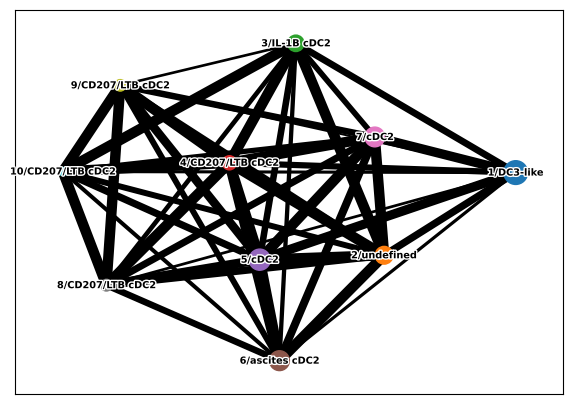

In [40]:
ax = sc.pl.paga(data_DC2, threshold=0.03, show=False)
# change text outline
for text in ax.texts:
    text.set_fontsize(7)
    text.set_color("black")
    text.set_path_effects([
        pe.Stroke(linewidth=2, foreground='white'),  # outline
        pe.Normal()
    ])

plt.show()

In [41]:
data_DC2

AnnData object with n_obs × n_vars = 16643 × 2001
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_type', 'cancer_type', 'patient_id', 'sample_id', 'percent.mt', 'site', 'sample_type_major', 'cancer_subtype', 'integration_id', 'ident', 'dataset_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'keep_or_remove', 'leiden', 'celltype', 'leiden_DC', 'leiden_DC_v2', 'exclude_annots', 'leiden_M', 'Technology', 'NR_annotations_simple', 'sample_type_major2', 'cancer_with_H', 'cancer_broadest', 'patient_treatment', 'Guimaraes_DC2_FCER1A', 'Guimaraes_DC2_AREG', 'Guimaraes_Cheng_DC2_CD207/CD1A', 'Guimaraes_DC3_CD14', 'Guimaraes_DC4_FCGR3A', 'Guimaraes_DC_CXCL2', 'Cheng_DC2_CXCR4', 'Cheng_DC2_IL1B', 'Cheng_DC2_FCN1', 'Cheng_DC2_ISG15', 'Cheng_DC2_CXCL9', 

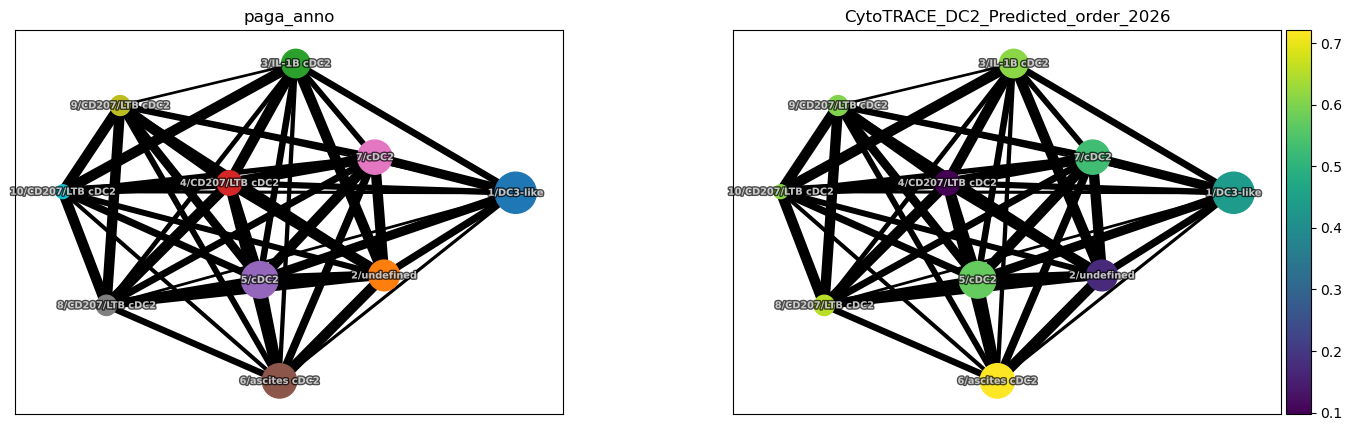

In [62]:
axes = sc.pl.paga(data_DC2, color=["paga_anno","CytoTRACE_DC2_Predicted_order_2026"], threshold=0.03, node_size_scale=3, show=False)
# change text outline
for ax in axes:
    for text in ax.texts:
        text.set_fontsize(7)
        text.set_color("white")
        text.set_alpha(0.7)
        text.set_path_effects([
            pe.Stroke(linewidth=2, foreground='black'),  # outline
            pe.Normal()
        ])

plt.show()

### recompute embedding using PAGA initialisation

In [13]:
sc.tl.draw_graph(data_DC2, init_pos="paga")

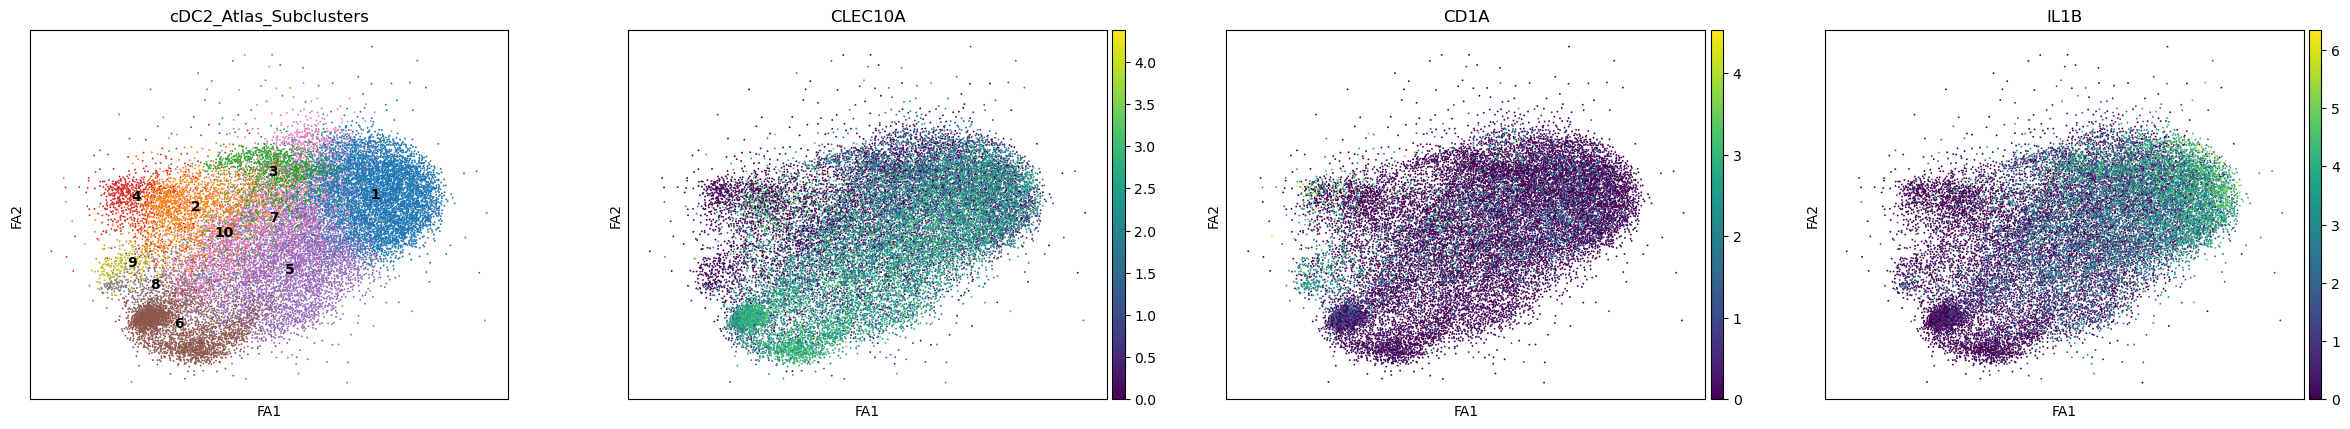

In [35]:
sc.pl.draw_graph(data_DC2, color=["cDC2_Atlas_Subclusters","CLEC10A","CD1A","IL1B"], legend_loc="on data")

# Choose a root cell based on cytotrace data (set as IL1B DC - cluster 3)

In [37]:
import numpy as np

In [38]:
data_DC2.uns["iroot"] = np.flatnonzero(data_DC2.obs["paga_anno"] == "3/IL-1B cDC2")[0]

In [39]:
sc.tl.dpt(data_DC2)

In [ ]:
sc.pl.draw_graph(data_DC2, color=["cDC2_Atlas_Subclusters", "CytoTRACE_DC2_Predicted_order_2026"], legend_loc="on data")

# Repeat above for AllDC

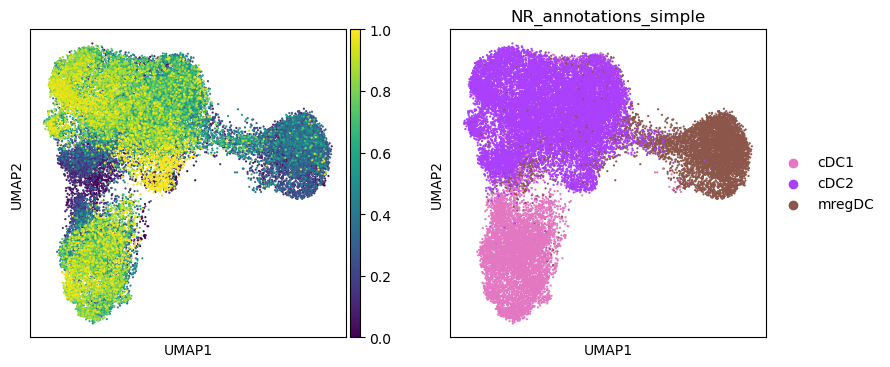

In [65]:
#plot cytotrace predictions. 1 --> less diff., 0 --> more diff.
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(data_DC, color=["CytoTRACE_DC_Predicted_order_2026","NR_annotations_simple"], size=10, title="")

### define ISG DC as it's own cluster based on cells with highest expression for ISG signature 

In [70]:
Moon_DC_ISG = ['ISG15', 'ISG20', 'CXCL9', 'CXCL10', 'IFIT1', 'IFIT3', 'IFI6', 'GBP2']

In [71]:
sc.tl.score_genes(data_DC, Moon_DC_ISG, score_name='Moon_DC_ISG_score')

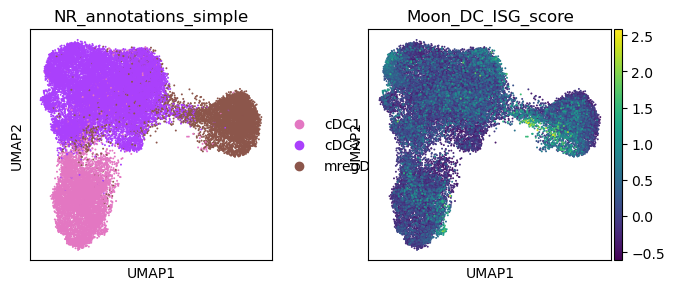

In [75]:
#plotting 
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(data_DC, color=["NR_annotations_simple","Moon_DC_ISG_score"], ncols=2, size=8)

In [89]:
# define ISG high cells as there own cluster
data_DC.obs["ISG_high"] = data_DC.obs["Moon_DC_ISG_score"] > 0.9

In [90]:
data_DC.obs["ISG_state"] = data_DC.obs["ISG_high"].map({
    True: "ISG-high",
    False: "ISG-low"
})

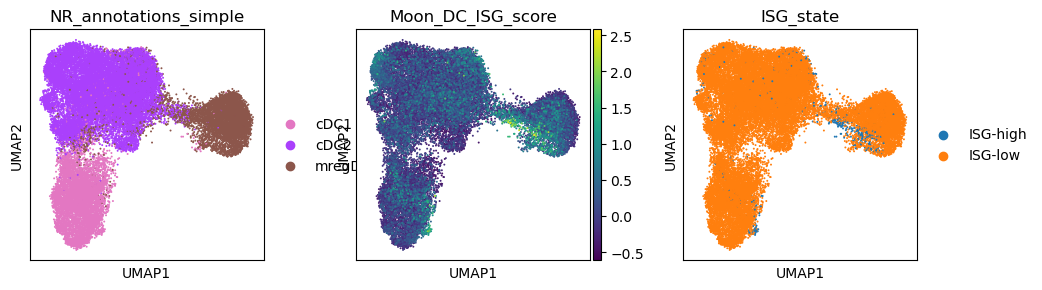

In [91]:
#plotting 
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(data_DC, color=["NR_annotations_simple","Moon_DC_ISG_score","ISG_state"], ncols=3, size=8)

In [96]:
#merge into other clusters
data_DC.obs["NR_annotations_ISG"] = data_DC.obs["NR_annotations_simple"].copy()
#add new category 
data_DC.obs["NR_annotations_ISG"] = data_DC.obs["NR_annotations_ISG"].cat.add_categories("ISG-high")
data_DC.obs.loc[
    data_DC.obs["ISG_state"] == "ISG-high",
    "NR_annotations_ISG"
] = "ISG-high"

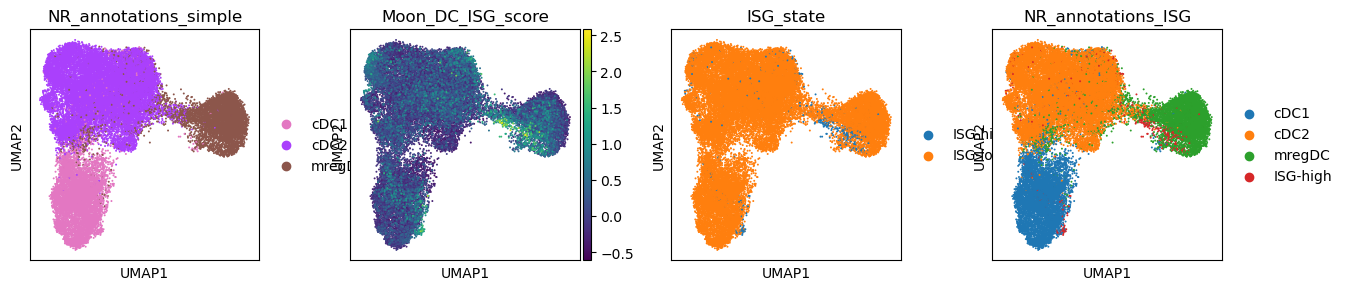

In [97]:
#plotting 
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(data_DC, color=["NR_annotations_simple","Moon_DC_ISG_score","ISG_state","NR_annotations_ISG"], ncols=4, size=8)

In [ ]:
sc.tl.paga(data_DC, groups="NR_annotations_simple")

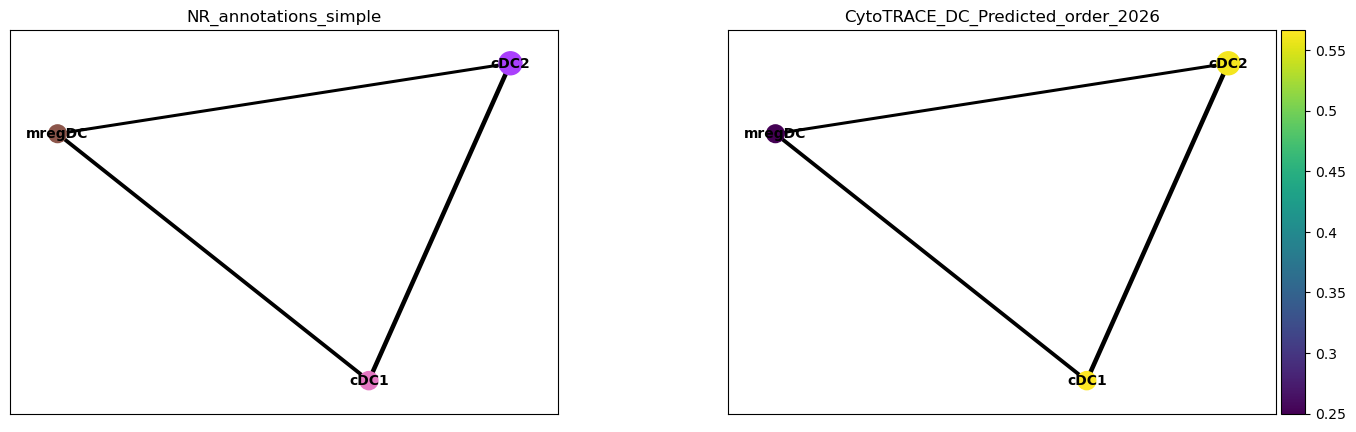

In [67]:
sc.pl.paga(data_DC, color=["NR_annotations_simple","CytoTRACE_DC_Predicted_order_2026"], threshold=0.03)

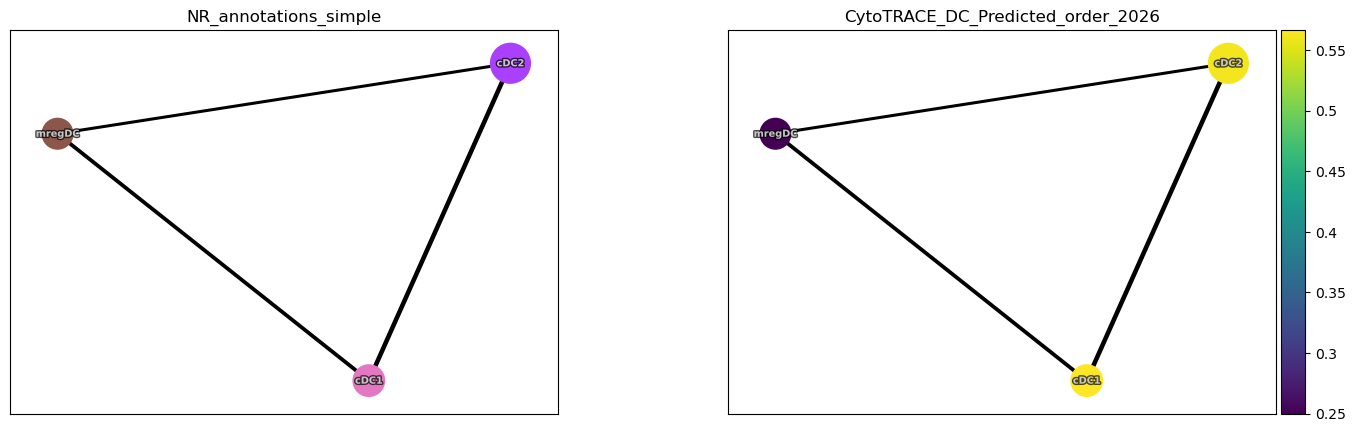

In [68]:
axes = sc.pl.paga(data_DC, color=["NR_annotations_simple","CytoTRACE_DC_Predicted_order_2026"], threshold=0.03, node_size_scale=3, show=False)
# change text outline
for ax in axes:
    for text in ax.texts:
        text.set_fontsize(7)
        text.set_color("white")
        text.set_alpha(0.7)
        text.set_path_effects([
            pe.Stroke(linewidth=2, foreground='black'),  # outline
            pe.Normal()
        ])

plt.show()

In [98]:
sc.tl.paga(data_DC, groups="NR_annotations_ISG")

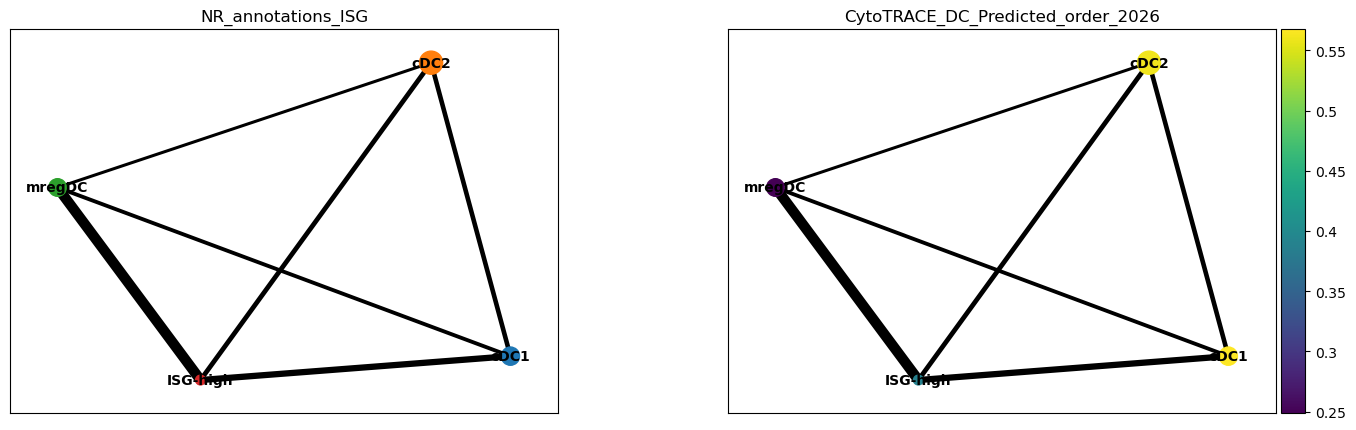

In [99]:
sc.pl.paga(data_DC, color=["NR_annotations_ISG","CytoTRACE_DC_Predicted_order_2026"], threshold=0.03)

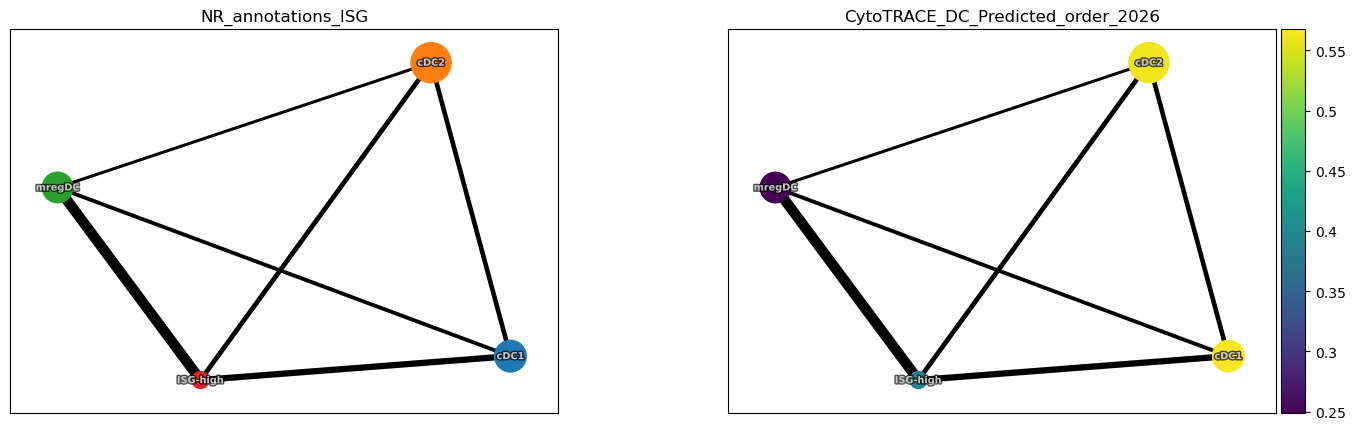

In [100]:
axes = sc.pl.paga(data_DC, color=["NR_annotations_ISG","CytoTRACE_DC_Predicted_order_2026"], threshold=0.03, node_size_scale=3, show=False)
# change text outline
for ax in axes:
    for text in ax.texts:
        text.set_fontsize(7)
        text.set_color("white")
        text.set_alpha(0.7)
        text.set_path_effects([
            pe.Stroke(linewidth=2, foreground='black'),  # outline
            pe.Normal()
        ])

plt.show()

In [ ]:
sc.tl.draw_graph(data_DC, init_pos="paga")

In [101]:
sc.pl.draw_graph(data_DC, color=["NR_annotations_ISG", "CytoTRACE_DC_Predicted_order_2026", "CLEC9A", "CD1C","LAMP3"], legend_loc="on data")

KeyError: 'draw_graph'